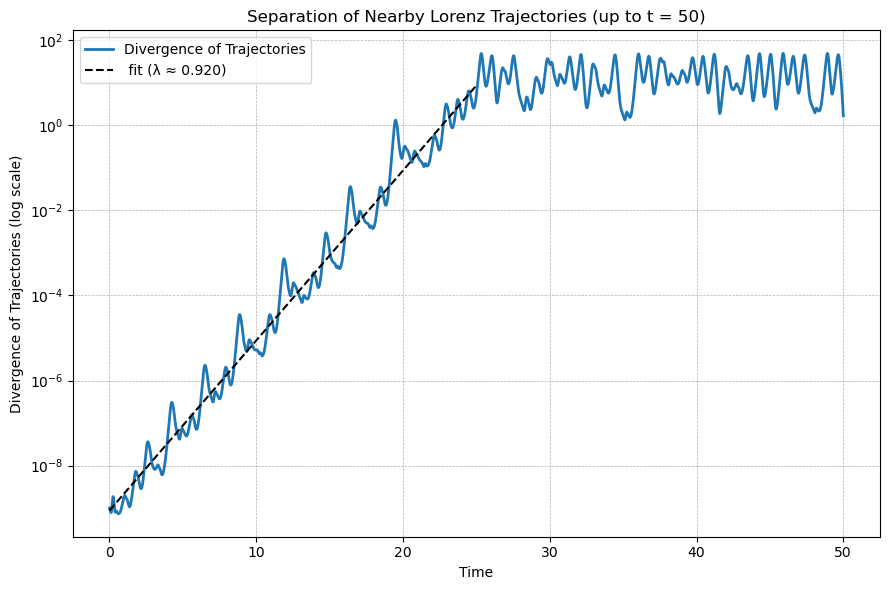

Estimated maximal Lyapunov exponent ≈ 0.9203


In [10]:
"""
Lyapunov Exponent of the Lorenz System (Extended to Show Saturation)
--------------------------------------------------------------------
Translated from Chebfun example (Hrothgar, 2015)
ChatGPT version, 2025
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Lorenz system definition
def lorenz(t, state, sigma=10.0, beta=8/3, rho=28.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Time domain extended to 50
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 20000)

# Initial conditions for two nearby trajectories
eps = 1e-9
y0_1 = np.array([2.0, 3.0, -14.0])
y0_2 = np.array([2.0, 3.0, -14.0 + eps])

# Integrate both trajectories
sol1 = solve_ivp(lorenz, t_span, y0_1, t_eval=t_eval, rtol=1e-9, atol=1e-12)
sol2 = solve_ivp(lorenz, t_span, y0_2, t_eval=t_eval, rtol=1e-9, atol=1e-12)

# Compute Euclidean distance between trajectories
d = np.sqrt(np.sum((sol1.y - sol2.y) ** 2, axis=0))

# Estimate Lyapunov exponent (linear region ~ first 25 time units)
mask = sol1.t < 25
logd = np.log(d[mask])
t_fit = sol1.t[mask]
coeffs = np.polyfit(t_fit, logd, 1)
slope = coeffs[0]

# Plot log-distance showing exponential phase and saturation
plt.figure(figsize=(9, 6))
plt.semilogy(sol1.t, d, label='Divergence of Trajectories', lw=2)
plt.semilogy(t_fit, np.exp(coeffs[1]) * np.exp(slope * t_fit),
             'k--', label=f' fit (λ ≈ {slope:.3f})')


plt.xlabel('Time')
plt.ylabel('Divergence of Trajectories (log scale)')
plt.title('Separation of Nearby Lorenz Trajectories (up to t = 50)')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Estimated maximal Lyapunov exponent ≈ {slope:.4f}")
